# Week 6 Model Tuning and Evaluation
**Goal**:Optimise a machine learning model using hyperparameter tuning and cross-validation, understanding the bias-variance tradeoff sa well.

## Step 1:Data Preparation

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV, validation_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            roc_auc_score, roc_curve, confusion_matrix, classification_report)

diabetes_df=pd.read_csv('Pima-Indians-Diabetes.csv')
print("Shape:",diabetes_df.shape)
diabetes_df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
diabetes_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Missing values:** `isnull()` reports no missing values but for this dataset, `0` is not a biologically valid value for Glucose, Blood Pressure, Skin Thickness, Insulin, or BMI. A `0` in these columns is actually a **hidden missing value** (a data-entry placeholder), so we treat it as such and impute it, rather than trusting `isnull()` alone.

In [4]:
print("Missing values:\n",diabetes_df.isnull().sum())
print("\nDuplicated rows:",diabetes_df.duplicated().sum())

zero_as_missing=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
print("\nZero counts in columns where 0 is not physiologically valid:")
print((diabetes_df[zero_as_missing]== 0).sum())

Missing values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Duplicated rows: 0

Zero counts in columns where 0 is not physiologically valid:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [5]:
# Treat 0 as missing in these columns and we impute median in them
diabetes_clean=diabetes_df.copy()
for col in zero_as_missing:
    diabetes_clean[col]=diabetes_clean[col].replace(0, np.nan)
    median_val=diabetes_clean[col].median()
    diabetes_clean[col]=diabetes_clean[col].fillna(median_val)

print("Remaining zeros after imputations:")
print((diabetes_clean[zero_as_missing]==0).sum())

Remaining zeros after imputations:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


No categorical variables need encoding, all features are numeric and outcome is binary. 

## Train/Test Split

In [6]:
X = diabetes_clean.drop(columns=['Outcome'])
y = diabetes_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set:  {X_test.shape[0]} rows")

Training set: 614 rows
Testing set:  154 rows


## Step 2:Baseline Model
We start with a Random Forest using default hyperparameters, to give us a reference point before any tuning.

In [8]:
baseline_rf=RandomForestClassifier(random_state=42)
baseline_rf.fit(X_train,y_train)
y_pred_base=baseline_rf.predict(X_test)
y_proba_base=baseline_rf.predict_proba(X_test)[:,1]

def evaluate(name, y_true, y_pred, y_proba):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }

baseline_scores = evaluate('Baseline (default params)', y_test, y_pred_base, y_proba_base)
baseline_scores

{'Model': 'Baseline (default params)',
 'Accuracy': 0.7792207792207793,
 'Precision': 0.7272727272727273,
 'Recall': 0.5925925925925926,
 'F1-Score': 0.6530612244897959,
 'ROC-AUC': 0.8191666666666666}

## Step 3:Cross-Validation
**K-Fold Cross-Validation** splits the training data into K equal folds. The model trains on K-1 folds and validates on the remaining fold, repeating K times so every fold is used for validation once. This gives a more reliable estimate of model performance than a single train/test split, since it isn't dependent on which rows happened to land in the test set.

We use 5-fold cross-validation on the baseline model.

In [10]:
cv=KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores=cross_val_score(baseline_rf,X_train, y_train, cv=cv, scoring='accuracy')

print("Cross-Validation accuracy per fold:",np.round(cv_scores, 4))
print(f"Mean CV Accuracy:{cv_scores.mean():.2%}")
print(f"Std Dev:{cv_scores.std():.4f}")

Cross-Validation accuracy per fold: [0.7154 0.7236 0.7886 0.813  0.7213]
Mean CV Accuracy:75.24%
Std Dev:0.0404


## Step 4:Hyperparameter Tuning
We compare two search strategies:
- **Grid Search**:exhaustively tries every combination of the specified parameter values.
- **Random Search**:samples a fixed number of random combinations, faster when the search space is large, at the cost of not checking every combination.

Both use 5-fold cross-validation internally to score each candidate.

In [12]:
param_grid={
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Grid Search Best Parameters:", grid_search.best_params_)
print(f"Grid Search Best CV Accuracy: {grid_search.best_score_:.2%}")




Grid Search Best Parameters: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}
Grid Search Best CV Accuracy: 77.37%


In [13]:
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(50, 400),
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': randint(2, 15),
    'min_samples_leaf': randint(1, 8)
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

print("Random Search Best Parameters:", random_search.best_params_)
print(f"Random Search Best CV Accuracy: {random_search.best_score_:.2%}")


Random Search Best Parameters: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 141}
Random Search Best CV Accuracy: 77.53%


## Step 5: Bias-Variance Tradeoff

- **Overfitting (high variance):** the model fits the training data too closely, including its noise, and fails to generalize to new data. Training accuracy is high; testing accuracy is much lower.
- **Underfitting (high bias):** the model is too simple to capture the real pattern, so it performs poorly on both training and testing data.
- **Model generalization** is the goal: performing well on data the model hasn't seen, not just the data it was trained on.

**Strategies for balancing bias and variance:**
- Increase model complexity (deeper trees, more estimators) to fix underfitting
- Add regularization, prune trees, or reduce complexity to fix overfitting
- Use cross-validation to detect the gap between training and validation performance before it shows up on the real test set
- Gather more/better training data to help the model generalize

We visualize this directly using a validation curve for `max_depth`, generated with cross-validation.

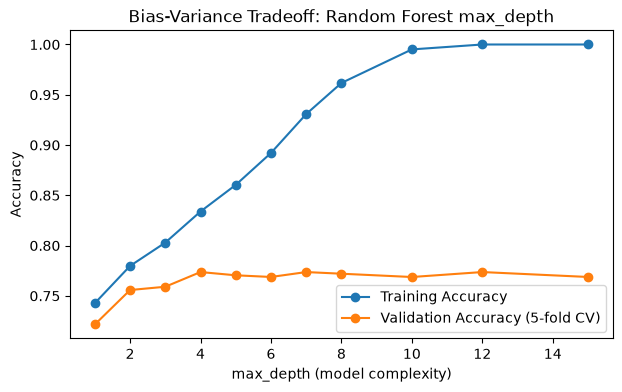

In [14]:
depth_range = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15]
train_scores, val_scores = validation_curve(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train, y_train,
    param_name='max_depth',
    param_range=depth_range,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

plt.figure(figsize=(7,4))
plt.plot(depth_range, train_scores.mean(axis=1), marker='o', label='Training Accuracy')
plt.plot(depth_range, val_scores.mean(axis=1), marker='o', label='Validation Accuracy (5-fold CV)')
plt.xlabel('max_depth (model complexity)')
plt.ylabel('Accuracy')
plt.title('Bias-Variance Tradeoff: Random Forest max_depth')
plt.legend()
plt.show()


**Reading the chart:** at low depth both scores are low (underfitting / high bias). As depth increases, training accuracy keeps climbing while validation accuracy plateaus and the gap between the two widens (overfitting / high variance) — the ideal depth is where validation accuracy is highest, just before that gap opens up.